In [1]:
import os
from tqdm.auto import tqdm
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


C:\Users\adrie\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [2]:
df = pd.read_csv("../data/dataset.csv")
df.shape

(110161, 16)

In [3]:
df.columns
df["state"].unique()

<StringArray>
['failed', 'successful']
Length: 2, dtype: str

In [4]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Load Embedding Model

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# embedding_model = SentenceTransformer(
#     'sentence-transformers/all-mpnet-base-v2',
#     cache_folder='./embedding_models',
#     device=device
# )

embedding_model = SentenceTransformer(
    'sentence-transformers/all-mpnet-base-v2',
    device=device
)
# C:\Users\adrie\.cache\huggingface


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2426.33it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Create embeddings (if not yet created)

In [6]:
if not (os.path.exists("../embeddings/train_embeddings.pt") and os.path.exists("../embeddings/test_embeddings.pt")):
    # Drop rows with missing blurbs or labels to avoid errors
    train_df = train_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)
    test_df = test_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)

    print(f"Training samples: {len(train_df)} | Test samples: {len(test_df)}")

    # Compute embeddings for train and test blurbs
    print("Encoding training blurbs...")
    train_embeddings = embedding_model.encode(train_df['blurb'].tolist(), show_progress_bar=True, convert_to_tensor=True)

    print("Encoding test blurbs...")
    test_embeddings = embedding_model.encode(test_df['blurb'].tolist(), show_progress_bar=True, convert_to_tensor=True)

    torch.save(train_embeddings, "embeddings/train_embeddings.pt")
    torch.save(test_embeddings, "embeddings/test_embeddings.pt")

else:
    train_embeddings = torch.load("../embeddings/train_embeddings.pt")
    test_embeddings = torch.load("../embeddings/test_embeddings.pt")


# Creating the Anchors

- Global Anchor: we aggregate all the success embeddings together and all the failed embeddings together and we have to global anchor to compare our embeddings to
- Anchors by category: for each category we create an anchor for the successful and failed blurbs and then we will compare to the anchors of the category for a more precise state prediction

In [8]:
# Ensure train_df is aligned with the saved embeddings (same dropna applied at encoding time)
train_df = train_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)
test_df  = test_df.dropna(subset=['blurb', 'category.parent_name', 'category.name']).reset_index(drop=True)

# 1. Compute Global State Anchors
state_anchors = {}
for state_category in train_df['state'].unique():
    mask = (train_df['state'] == state_category).values
    state_anchors[state_category] = train_embeddings[mask].mean(dim=0)

# 2. Compute State Anchors for each category
category_state_anchors = {}
for parent_category in train_df['category.parent_name'].unique():
    for state_category in train_df['state'].unique():
        mask = (
            (train_df['category.parent_name'] == parent_category) &
            (train_df['state'] == state_category)
        ).values
        if mask.sum() > 0:
            category_state_anchors[(parent_category, state_category)] = train_embeddings[mask].mean(dim=0)

print(f"Created {len(state_anchors)} state anchors and {len(category_state_anchors)} category state anchors.")

Created 2 state anchors and 30 category state anchors.


## Prediction Global Anchor

In [9]:
# for each test embedding, compute cosine similarity from the global anchor by state and decide which state to predict
test_predictions = []
for test_emb in tqdm(test_embeddings, desc="Predicting states"):
    # Compute cosine similarity to each state anchor
    similarities = {state: util.cos_sim(test_emb, anchor).item() for state, anchor in state_anchors.items()}
    
    # Predict the state with the highest similarity
    predicted_state = max(similarities, key=similarities.get)
    test_predictions.append(predicted_state)

Predicting states: 100%|██████████| 21297/21297 [00:02<00:00, 7752.76it/s]


Classification Report:
              precision    recall  f1-score   support

      failed       0.58      0.63      0.60      8642
  successful       0.73      0.69      0.71     12655

    accuracy                           0.66     21297
   macro avg       0.66      0.66      0.66     21297
weighted avg       0.67      0.66      0.67     21297

Confusion Matrix:


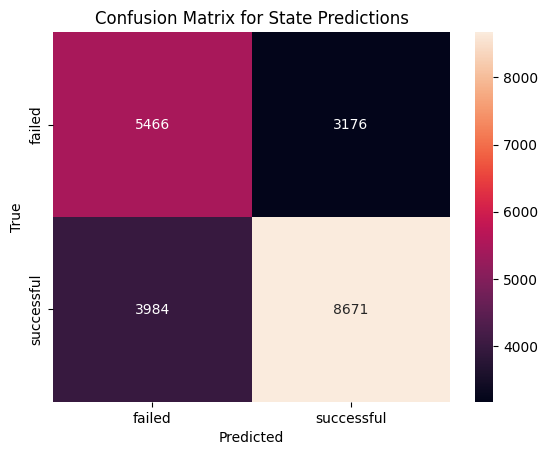

In [10]:
# evaluation, create me a confusion matrix and classification report
true_states = test_df['state'].tolist()
print("Classification Report:")
print(classification_report(true_states, test_predictions))
print("Confusion Matrix:")
cm = confusion_matrix(true_states, test_predictions, labels=list(state_anchors.keys()))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=state_anchors.keys(), yticklabels=state_anchors.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for State Predictions')
plt.show()

In [13]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# 1. Global Accuracy
accuracy = accuracy_score(true_states, test_predictions)

# 2. Global F1-Score (Macro or Weighted)
# 'weighted' accounts for label imbalance, 'macro' treats all classes equally
f1 = f1_score(true_states, test_predictions, average='weighted')

print(f"Global Accuracy: {accuracy:.4f}")
print(f"Global F1-Score (Weighted): {f1:.4f}")

# 3. AUC-Score
# Note: This requires probability estimates. Replace 'test_probs' with your model's output probabilities.
try:
    # multi_class='ovr' (One-vs-Rest) is standard for multi-class AUC
    auc = roc_auc_score(true_states, test_probs, multi_class='ovr', average='weighted')
    print(f"Global AUC-Score: {auc:.4f}")
except NameError:
    print("Global AUC-Score: Could not calculate (probabilities 'test_probs' not found).")

Global Accuracy: 0.6638
Global F1-Score (Weighted): 0.6658
Global AUC-Score: Could not calculate (probabilities 'test_probs' not found).


## Prediction using Anchor by category

In [11]:
# for each test embedding, compute cosine similarity from the anchors by state of its category and decide which state to predict
test_predictions_category = []
for idx, test_emb in tqdm(enumerate(test_embeddings), desc="Predicting states by category", total=len(test_embeddings)):
    parent_category = test_df.iloc[idx]['category.parent_name']

    # Get all state anchors available for this parent category
    category_anchors = {
        state: anchor
        for (cat, state), anchor in category_state_anchors.items()
        if cat == parent_category
    }

    if category_anchors:
        # Compute cosine similarity to each state anchor and pick the best one
        similarities = {state: util.cos_sim(test_emb, anchor).item() for state, anchor in category_anchors.items()}
        predicted_state = max(similarities, key=similarities.get)
    else:
        # Fall back to global anchors when no category-specific anchors are available
        similarities = {state: util.cos_sim(test_emb, anchor).item() for state, anchor in state_anchors.items()}
        predicted_state = max(similarities, key=similarities.get)

    test_predictions_category.append(predicted_state)


Predicting states by category: 100%|██████████| 21297/21297 [00:05<00:00, 3580.37it/s]


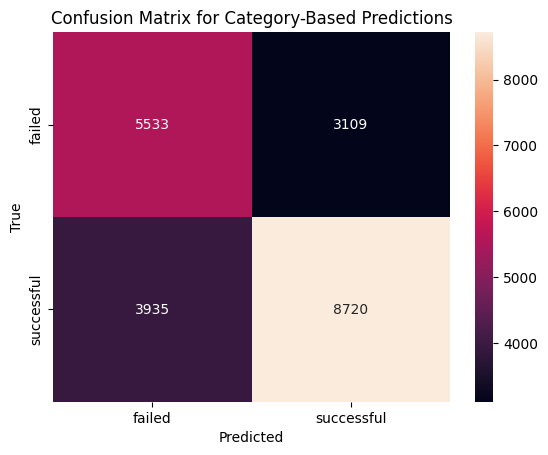

In [12]:
# plot one confusion matrix for the each category
cm_category = confusion_matrix(true_states, test_predictions_category, labels=list(state_anchors.keys()))
sns.heatmap(cm_category, annot=True, fmt='d', xticklabels=state_anchors.keys(), yticklabels=state_anchors.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Category-Based Predictions')
plt.show()

In [16]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_recall_fscore_support
import pandas as pd
import numpy as np

# 1. Add predictions to your dataframe for easy grouping
test_df['predicted_state'] = test_predictions_category
test_df['true_state'] = true_states

categories = test_df['category.parent_name'].unique()
category_metrics = []

for cat in categories:
    cat_df = test_df[test_df['category.parent_name'] == cat]
    
    if len(cat_df) == 0:
        continue
        
    y_true = cat_df['true_state']
    y_pred = cat_df['predicted_state']
    
    # Calculate metrics for this specific category
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    # Weight is usually based on the number of samples in the category
    weight = len(cat_df)
    
    category_metrics.append({
        'category': cat,
        'accuracy': acc,
        'f1': f1,
        'weight': weight
    })

# 2. Convert to DataFrame to calculate weighted averages
metrics_df = pd.DataFrame(category_metrics)
total_samples = metrics_df['weight'].sum()

global_weighted_acc = (metrics_df['accuracy'] * metrics_df['weight']).sum() / total_samples
global_weighted_f1 = (metrics_df['f1'] * metrics_df['weight']).sum() / total_samples

print(f"Global Weighted Accuracy: {global_weighted_acc:.4f}")
print(f"Global Weighted F1 Score: {global_weighted_f1:.4f}")

# Note on AUC: AUC requires probability scores (distances) rather than hard labels.
# If you have multi-class labels, calculating a 'weighted average AUC' per category 
# is mathematically complex unless every category contains all possible classes.

Global Weighted Accuracy: 0.6692
Global Weighted F1 Score: 0.6806
